<a href="https://colab.research.google.com/github/taru30174/my-_projects/blob/main/AI_powered_salesforecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data sample:
    year         sales
48  1976  1.873412e+12
47  1977  2.081826e+12
46  1978  2.351599e+12
45  1979  2.627333e+12
44  1980  2.857307e+12


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


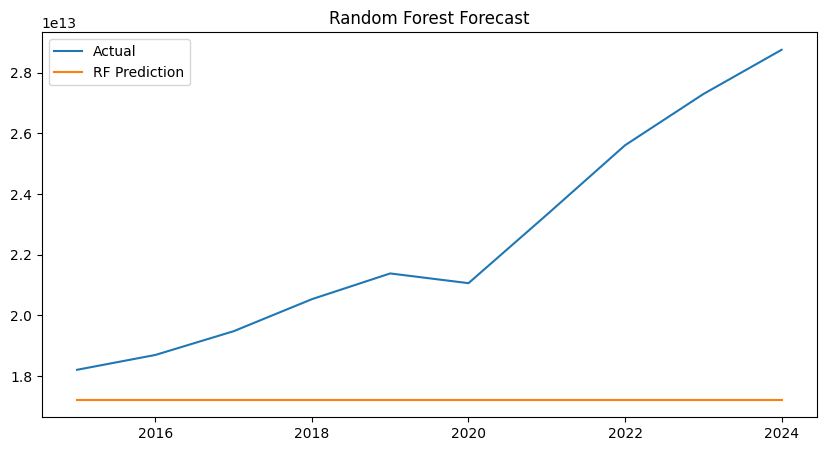

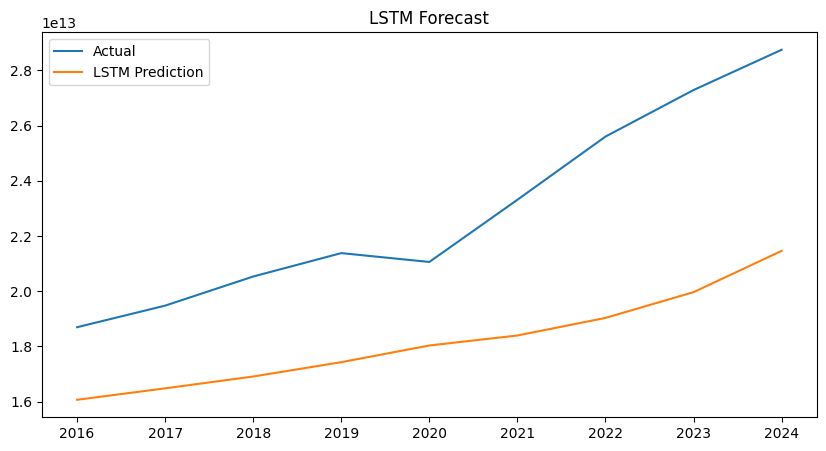

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ----------------------------------
# 1. Fetch Data from API
# ----------------------------------

url = "https://api.worldbank.org/v2/country/USA/indicator/NY.GDP.MKTP.CD?format=json"

response = requests.get(url)
data_json = response.json()

data = data_json[1]

records = []

for entry in data:
    if entry["value"] is not None:
        records.append({
            "year": int(entry["date"]),
            "sales": float(entry["value"])
        })

df = pd.DataFrame(records)
df = df.sort_values("year")

print("Data sample:")
print(df.head())

# ----------------------------------
# 2. Feature Engineering
# ----------------------------------

df["lag_1"] = df["sales"].shift(1)
df["lag_2"] = df["sales"].shift(2)
df = df.dropna()

# ----------------------------------
# 3. ML Model (Random Forest)
# ----------------------------------

X = df[["lag_1", "lag_2"]]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# ----------------------------------
# 4. Deep Learning Model (LSTM)
# ----------------------------------

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[["sales"]])

sequence_length = 3
X_seq = []
y_seq = []

for i in range(len(scaled_data) - sequence_length):
    X_seq.append(scaled_data[i:i+sequence_length])
    y_seq.append(scaled_data[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

model = Sequential([
    LSTM(50, activation="relu", input_shape=(sequence_length, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train_seq, y_train_seq, epochs=50, verbose=0)

lstm_pred = model.predict(X_test_seq)
lstm_pred = scaler.inverse_transform(lstm_pred)

# ----------------------------------
# 5. Visualization
# ----------------------------------

plt.figure(figsize=(10,5))
plt.plot(df["year"][-len(y_test):], y_test, label="Actual")
plt.plot(df["year"][-len(rf_pred):], rf_pred, label="RF Prediction")
plt.title("Random Forest Forecast")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["year"][-len(lstm_pred):],
         scaler.inverse_transform(y_test_seq.reshape(-1,1)),
         label="Actual")
plt.plot(df["year"][-len(lstm_pred):], lstm_pred, label="LSTM Prediction")
plt.title("LSTM Forecast")
plt.legend()
plt.show()